In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
FOLDERS = {
    "data/full-drumstick/test2-0": "No fracture hammer 1",
    "data/full-drumstick/test2-100": "100% Fracture hammer 1",
    "data/full-drumstick/test3-0": "No fracture hammer 2",
    "data/full-drumstick/test3-100": "100% Fracture hammer 2"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(impedances)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture hammer 1: 6 files loaded
100% Fracture hammer 1: 15 files loaded
No fracture hammer 2: 11 files loaded
100% Fracture hammer 2: 14 files loaded


# Outlier Detection

In [10]:
print("OUTLIER REPORT")
print("=" * 40)

for group_name, data in group_data.items():

    sweep_means = np.mean(
        data["raw"],
        axis=1
    )

    z_scores = np.abs(
        zscore(sweep_means)
    )

    outliers = np.where(
        z_scores > 2.5
    )[0]

    print(f"\n{group_name}")

    if len(outliers) == 0:
        print("No outliers found")

    else:
        print(f"Outliers: {outliers}")

OUTLIER REPORT

No fracture hammer 1
No outliers found

100% Fracture hammer 1
No outliers found

No fracture hammer 2
Outliers: [3]

100% Fracture hammer 2
Outliers: [9]


# PCA Analysis

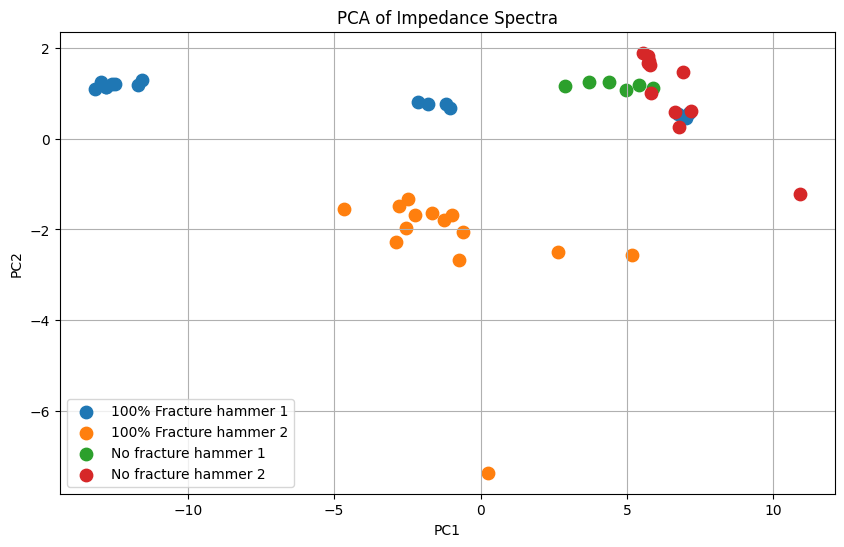

In [14]:
X = []
y = []

for group_name, data in group_data.items():

    for sweep in data["raw"]:
        X.append(sweep)
        y.append(group_name)

X = np.array(X)

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.style.use("default")

plt.figure(figsize=(10, 6))

for group_name in np.unique(y):
    mask = np.array(y) == group_name

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=80,
        label=group_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Impedance Spectra")
plt.legend()
plt.grid()

plt.savefig(
    "pca comparison hammer test.png",
    dpi=300
)

plt.show()

# extra PCA

In [12]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))


[0.91200294 0.0633433 ]
0.9753462428822282


In [13]:
print(plt.rcParams['figure.facecolor'])
print(plt.rcParams['axes.facecolor'])

#191a1c
#191a1c
